# Step 4: Exploratory Data Analysis (EDA)

In this notebook, we will perform the following steps:
1.  Load the processed data splits (`train_split.csv` and `val_split.csv`).
2.  Analyze and visualize the class distribution (Normal vs. Pneumonia).
3.  Calculate the class imbalance ratio.
4.  Plot sample images from each class.
5.  Document key observations.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import sys
import numpy as np

# --- CONFIGURATION ---

# Set our paths relative to the notebook's location in 'notebooks/'
PROCESSED_DIR = Path("../data/processed")
SRC_DIR = Path("../src")

# Add the 'src' directory to our Python path
# This allows us to import our custom 'PneumoniaDataset' class
sys.path.append(str(SRC_DIR))

# Now we can import our class
try:
    # Assuming your file is src/data_preprocessing.py
    from data_preprocessing import PneumoniaDataset
    print("Successfully imported PneumoniaDataset from src/data_preprocessing.py")
except ImportError:
    print("Error: Could not import PneumoniaDataset.")
    print("Make sure 'src/data_preprocessing.py' exists and is correct.")

# Set plot style
sns.set(style="whitegrid", context="talk")

Successfully imported PneumoniaDataset from src/data_preprocessing.py


## 1. Load Data and Check Class Distribution (Tasks 2 & 3)

Total images in combined dataset: 5856

Class Counts:
label
Pneumonia    4273
Normal       1583
Name: count, dtype: int64

Imbalance Ratio (Pneumonia to Normal): 2.70 : 1
This means there are 2.70 pneumonia cases for every 1 normal case.


C:\Users\rajat\AppData\Local\Temp\ipykernel_17812\4011030693.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=all_data_df, palette=["skyblue", "salmon"])


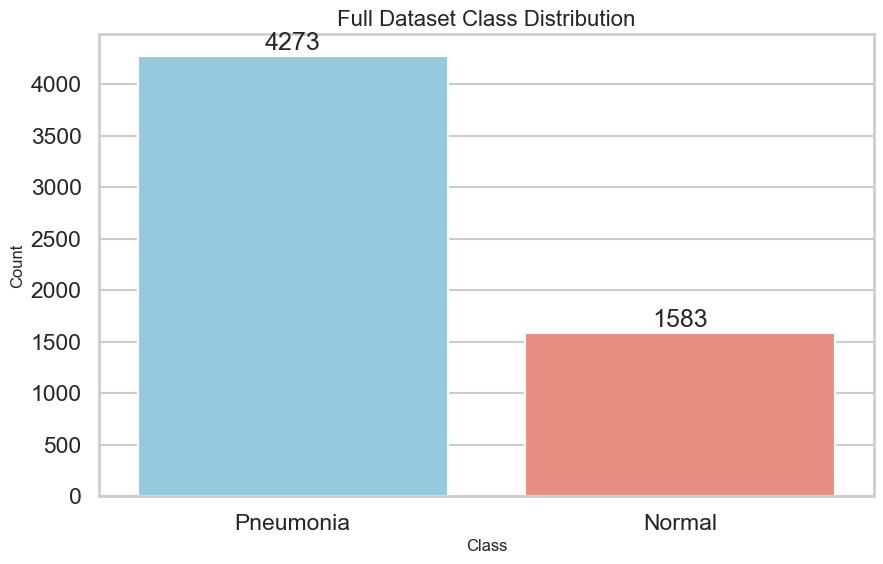

In [5]:
# Load the CSV files
train_df = pd.read_csv(PROCESSED_DIR / "train_split.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val_split.csv")

# Combine them for a full dataset overview
all_data_df = pd.concat([train_df, val_df])
# Map labels to human-readable names for plotting
all_data_df['label'] = all_data_df['label'].map({0: 'Normal', 1: 'Pneumonia'})

print(f"Total images in combined dataset: {len(all_data_df)}\n")

# Calculate counts and imbalance ratio
counts = all_data_df['label'].value_counts()
print("Class Counts:")
print(counts)

pneumonia_count = counts.get('Pneumonia', 0)
normal_count = counts.get('Normal', 0)

if normal_count > 0:
    imbalance_ratio = pneumonia_count / normal_count
    print(f"\nImbalance Ratio (Pneumonia to Normal): {imbalance_ratio:.2f} : 1")
    print(f"This means there are {imbalance_ratio:.2f} pneumonia cases for every 1 normal case.")
else:
    print("\nCannot calculate imbalance ratio: No 'Normal' cases found.")

# Visualize the distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=all_data_df, palette=["skyblue", "salmon"])
ax.set_title("Full Dataset Class Distribution", fontsize=16)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')
plt.show()

## 2. Plot Sample Images (Task 1)

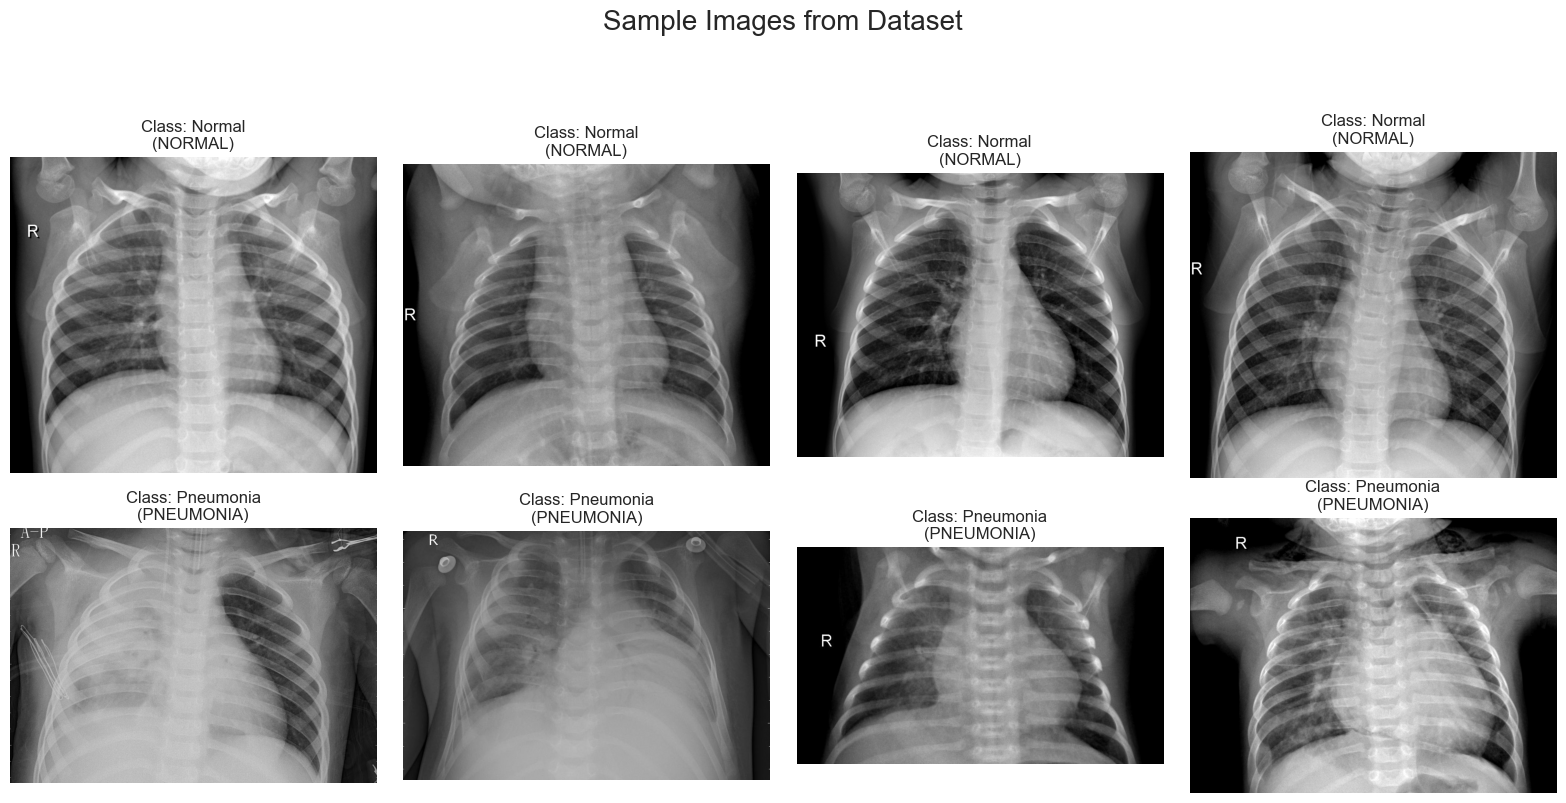

In [6]:
def plot_sample_images(df, n=4):
    """Plots n sample images for both Normal and Pneumonia classes."""
    
    # Get n random samples from each class
    normal_samples = df[df['label'] == 'Normal'].sample(n, random_state=42)
    pneumonia_samples = df[df['label'] == 'Pneumonia'].sample(n, random_state=42)
    
    # Create the plot
    fig, axes = plt.subplots(2, n, figsize=(n * 4, 8))
    fig.suptitle("Sample Images from Dataset", fontsize=20, y=1.05)
    
    # Plot Normal images
    for i, (idx, row) in enumerate(normal_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"Class: {row['label']}\n(NORMAL)", fontsize=12)
        axes[0, i].axis('off')
        
    # Plot Pneumonia images
    for i, (idx, row) in enumerate(pneumonia_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f"Class: {row['label']}\n(PNEUMONIA)", fontsize=12)
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Plot 4 samples from each class
plot_sample_images(all_data_df, n=4)

## 3. Document Observations (Task 4)

Based on the analysis above, we have two critical observations:

**1. Significant Class Imbalance:**

* **Observation:** The dataset is heavily imbalanced, with a ratio of approximately **2.7:1** (Pneumonia to Normal). For every 1 "Normal" image, we have almost 3 "Pneumonia" images.
* **Impact on Training:** If we use a standard loss function, the model will be heavily biased towards predicting "Pneumonia" because it's the majority class. It will get a high accuracy score simply by guessing the majority, which is misleading.
* **Action:** * We **must not** rely on **Accuracy** as our primary evaluation metric. 
    * We **must** prioritize metrics like **F1-Score**, **Precision**, **Recall**, and the **AUC-ROC curve**.
    * During training (Step 5), we should consider using a **weighted loss function** (like `nn.BCEWithLogitsLoss` with the `pos_weight` argument) to give more importance to the minority "Normal" class.

**2. Image Quality and Variation:**

* **Observation:** The sample images show considerable variation. Some images are high contrast, others are low contrast, and some have varying levels of brightness. We can also see diagnostic markers and text on some images. The pneumonia opacity itself can be very faint and hard to see, or it can cover a large portion of the lung. 
* **Impact on Training:** The model needs to be robust to these variations and learn to focus on the pathological features, not the noise or artifacts.
* **Action:** * The `transforms.Resize` is a good first step for standardization.
    * For our **training** data loader, we should add **data augmentation** (like `transforms.RandomRotation`, `transforms.RandomHorizontalFlip`, and `transforms.ColorJitter` for brightness/contrast) to create more varied training examples and prevent overfitting.